In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/churn_clean.csv')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print("Shape:", df.shape)
print("Churn rate:", df['Churn'].mean().round(3))
df.head()

Shape: (5630, 19)
Churn rate: 0.168


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1,1,5,159.93
1,1,9.0,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0,1,0,120.90
2,1,9.0,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0,1,3,120.28
3,1,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0,1,3,134.07
4,1,0.0,Mobile,1,12.0,Credit Card,Male,3.0,3,Mobile,5,Single,3,0,11.0,1,1,3,129.60


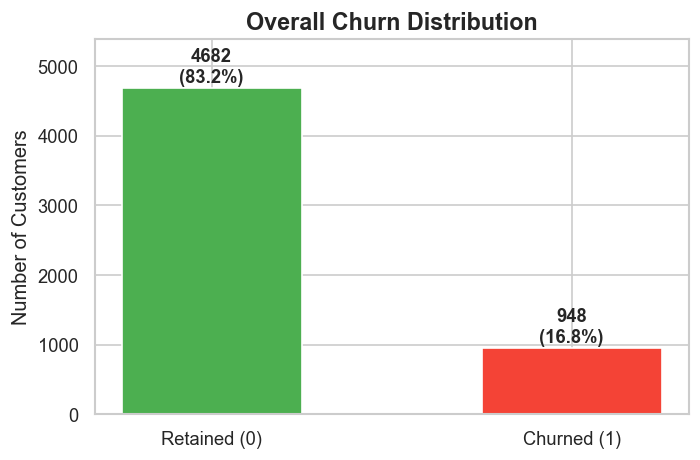

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()

bars = ax.bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
              color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)

for bar, count in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('../data/processed/plot_01_churn_distribution.png')
plt.show()

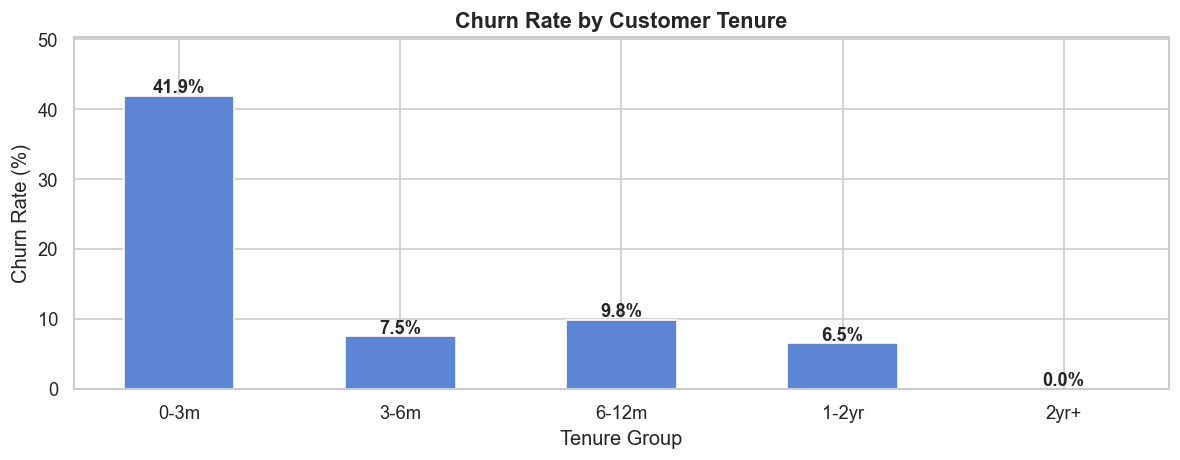

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

df['TenureBin'] = pd.cut(df['Tenure'], bins=[-1, 3, 6, 12, 24, 100],
                          labels=['0-3m', '3-6m', '6-12m', '1-2yr', '2yr+'])

churn_by_tenure = df.groupby('TenureBin', observed=True)['Churn'].mean() * 100

bars = ax.bar(churn_by_tenure.index, churn_by_tenure.values,
              color='#5C85D6', edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_by_tenure.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Customer Tenure', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, churn_by_tenure.max() * 1.2)
plt.tight_layout()
plt.savefig('../data/processed/plot_02_churn_by_tenure.png')
plt.show()

df.drop(columns=['TenureBin'], inplace=True)

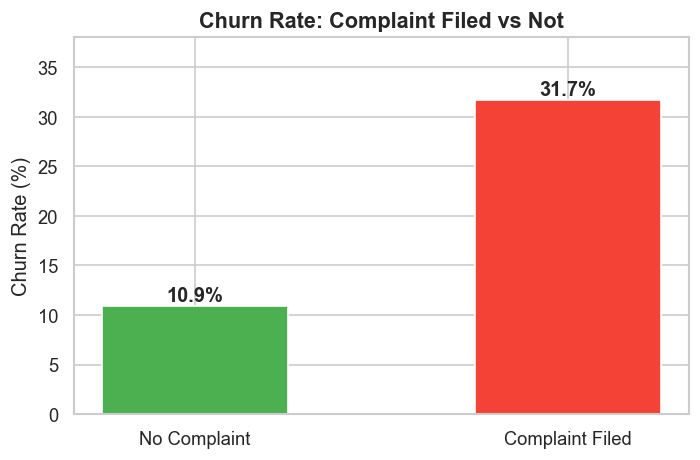

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

complain_churn = df.groupby('Complain')['Churn'].mean() * 100

bars = ax.bar(['No Complaint', 'Complaint Filed'],
              complain_churn.values,
              color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)

for bar, val in zip(bars, complain_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Churn Rate: Complaint Filed vs Not', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, complain_churn.max() * 1.2)
plt.tight_layout()
plt.savefig('../data/processed/plot_03_churn_by_complaint.png')
plt.show()

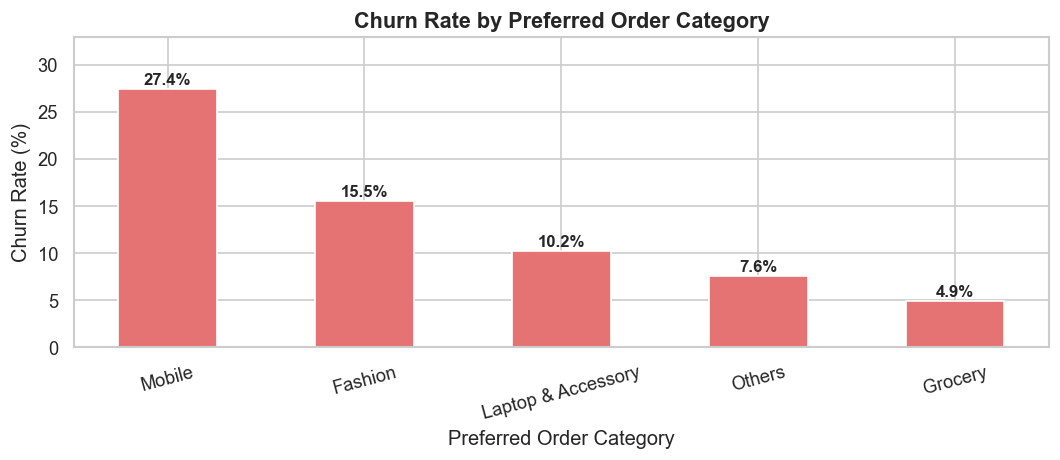

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))

churn_by_cat = df.groupby('PreferredOrderCat')['Churn'].mean().sort_values(ascending=False) * 100

bars = ax.bar(churn_by_cat.index, churn_by_cat.values,
              color='#E57373', edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_by_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Churn Rate by Preferred Order Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Preferred Order Category')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, churn_by_cat.max() * 1.2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/plot_04_churn_by_category.png')
plt.show()

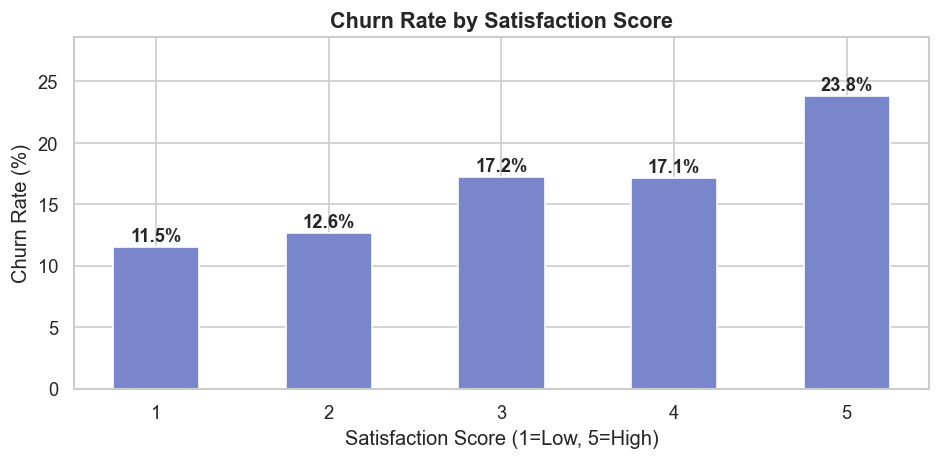

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

churn_by_sat = df.groupby('SatisfactionScore')['Churn'].mean() * 100

bars = ax.bar(churn_by_sat.index, churn_by_sat.values,
              color='#7986CB', edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_by_sat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Satisfaction Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Satisfaction Score (1=Low, 5=High)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, churn_by_sat.max() * 1.2)
plt.tight_layout()
plt.savefig('../data/processed/plot_05_churn_by_satisfaction.png')
plt.show()

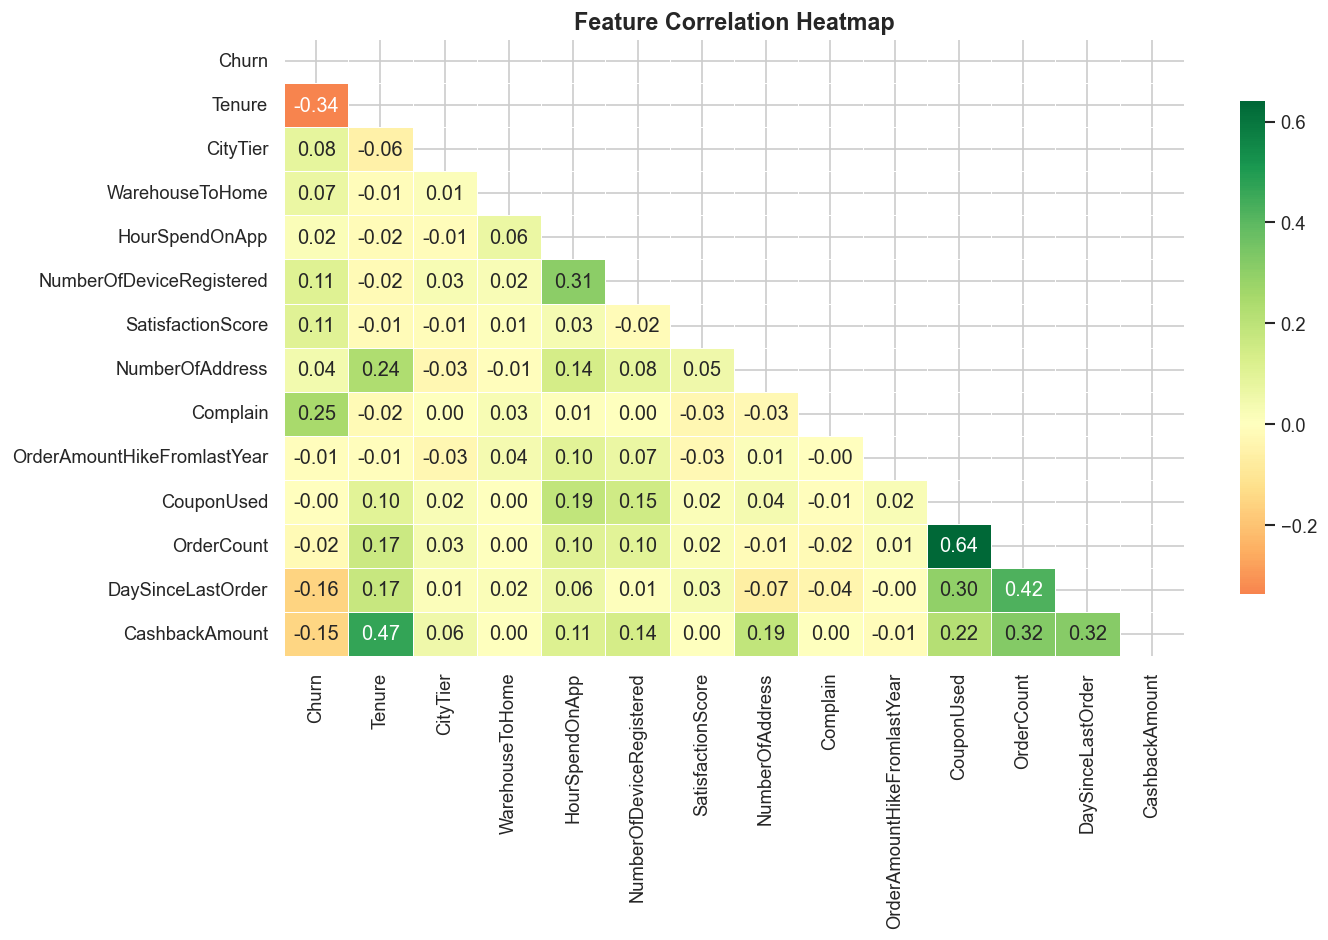

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot_06_correlation_heatmap.png')
plt.show()

In [ ]:
## Key Business Insights from EDA

1. TENURE IS EVERYTHING: Customers in their first 3 months churn at 41.9%
   vs 0% for 2yr+ customers. The first 90 days are the highest-risk window.
   → Launch a "First 90 Days" onboarding loyalty program immediately.

2. COMPLAINTS = CHURN: Customers who filed a complaint churn at 31.7%
   vs 10.9% for those who didn't — 3x higher risk.
   → Implement 24-hour complaint resolution SLA for all first-time complainants.

3. MOBILE BUYERS ARE DISLOYAL: Mobile category customers churn at 27.4%,
   nearly double the overall rate of 16.8%. Price-sensitive, platform-agnostic.
   → Run targeted cashback campaigns exclusively for mobile category buyers.

4. SATISFACTION PARADOX: Score-5 customers churn at 23.8% — the highest
   of any satisfaction group. Satisfaction alone does not predict loyalty.
   → Replace satisfaction surveys with engagement metrics (recency, frequency).

5. CASHBACK BUILDS LOYALTY: CashbackAmount has -0.15 correlation with churn.
   Customers earning less cashback leave more.
   → Introduce tiered cashback — increase rewards as a retention tool
     before customers show inactivity signals.